# Bayesian State Space Models for Financial Regime Detection

This notebook demonstrates how to use PyMC to build Bayesian state space models
for detecting market regimes in financial time series data.

State space models are a foundational tool in quantitative finance — they allow us to:
- Infer latent (unobserved) market states (e.g., bull/bear, high/low volatility)
- Update beliefs sequentially as new data arrives
- Quantify uncertainty in regime assignments

We implement two models:
1. **Local Level Model** — a simple random walk + noise model for trend estimation
2. **Markov Switching Model** — a two-regime model for bull/bear detection

This is directly motivated by the
[Scalable Online Bayesian State Space Models GSoC 2026 project](https://github.com/pymc-devs/pymc/wiki/GSoC-2026-projects).

**Author:** Pooja Venugopal Baskaran  
**GitHub:** https://github.com/Pooja2420

In [1]:
!pip install graphviz


In [2]:
import os
os.environ["PYTENSOR_FLAGS"] = "cxx=,blas__ldflags="
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from datetime import datetime, timedelta

rng = np.random.default_rng(42)
print(f'PyMC version: {pm.__version__}')
print(f'ArviZ version: {az.__version__}')
%config InlineBackend.figure_format = 'retina'
plt.style.use('bmh')
az.style.use('arviz-darkgrid')

PyMC version: 5.28.3
ArviZ version: 0.23.4


## 1. Simulate Financial Time Series Data

We simulate a realistic financial return series with two regimes:
- **Regime 0 (Bear):** low mean, high volatility
- **Regime 1 (Bull):** high mean, low volatility

This mimics real market behaviour — volatility clustering and regime persistence.

In [3]:
# Simulate regime-switching financial returns
T = 200  # number of time steps

# Regime parameters
regime_means = [-0.001, 0.001]   # bear, bull
regime_vols  = [0.025, 0.010]    # bear=high vol, bull=low vol
transition_probs = np.array([[0.97, 0.03],   # P(stay bear | bear)
                              [0.02, 0.98]])  # P(stay bull | bull)

# Generate regimes via Markov chain
true_regimes = np.zeros(T, dtype=int)
true_regimes[0] = 0  # start in bear regime
for t in range(1, T):
    true_regimes[t] = rng.choice(2, p=transition_probs[true_regimes[t-1]])

# Generate returns conditional on regime
returns = np.array([
    rng.normal(regime_means[r], regime_vols[r])
    for r in true_regimes
])

# Create date index
start_date = datetime(2020, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(T)]

# Cumulative price series
prices = 100 * np.exp(np.cumsum(returns))

print(f'Simulated {T} daily returns')
print(f'Bear regime days: {(true_regimes==0).sum()} ({(true_regimes==0).mean()*100:.1f}%)')
print(f'Bull regime days: {(true_regimes==1).sum()} ({(true_regimes==1).mean()*100:.1f}%)')

Simulated 200 daily returns
Bear regime days: 132 (66.0%)
Bull regime days: 68 (34.0%)


/var/folders/cl/4ndd0vrd3mvb87d9zdzyv_240000gn/T/ipykernel_25865/2604239121.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


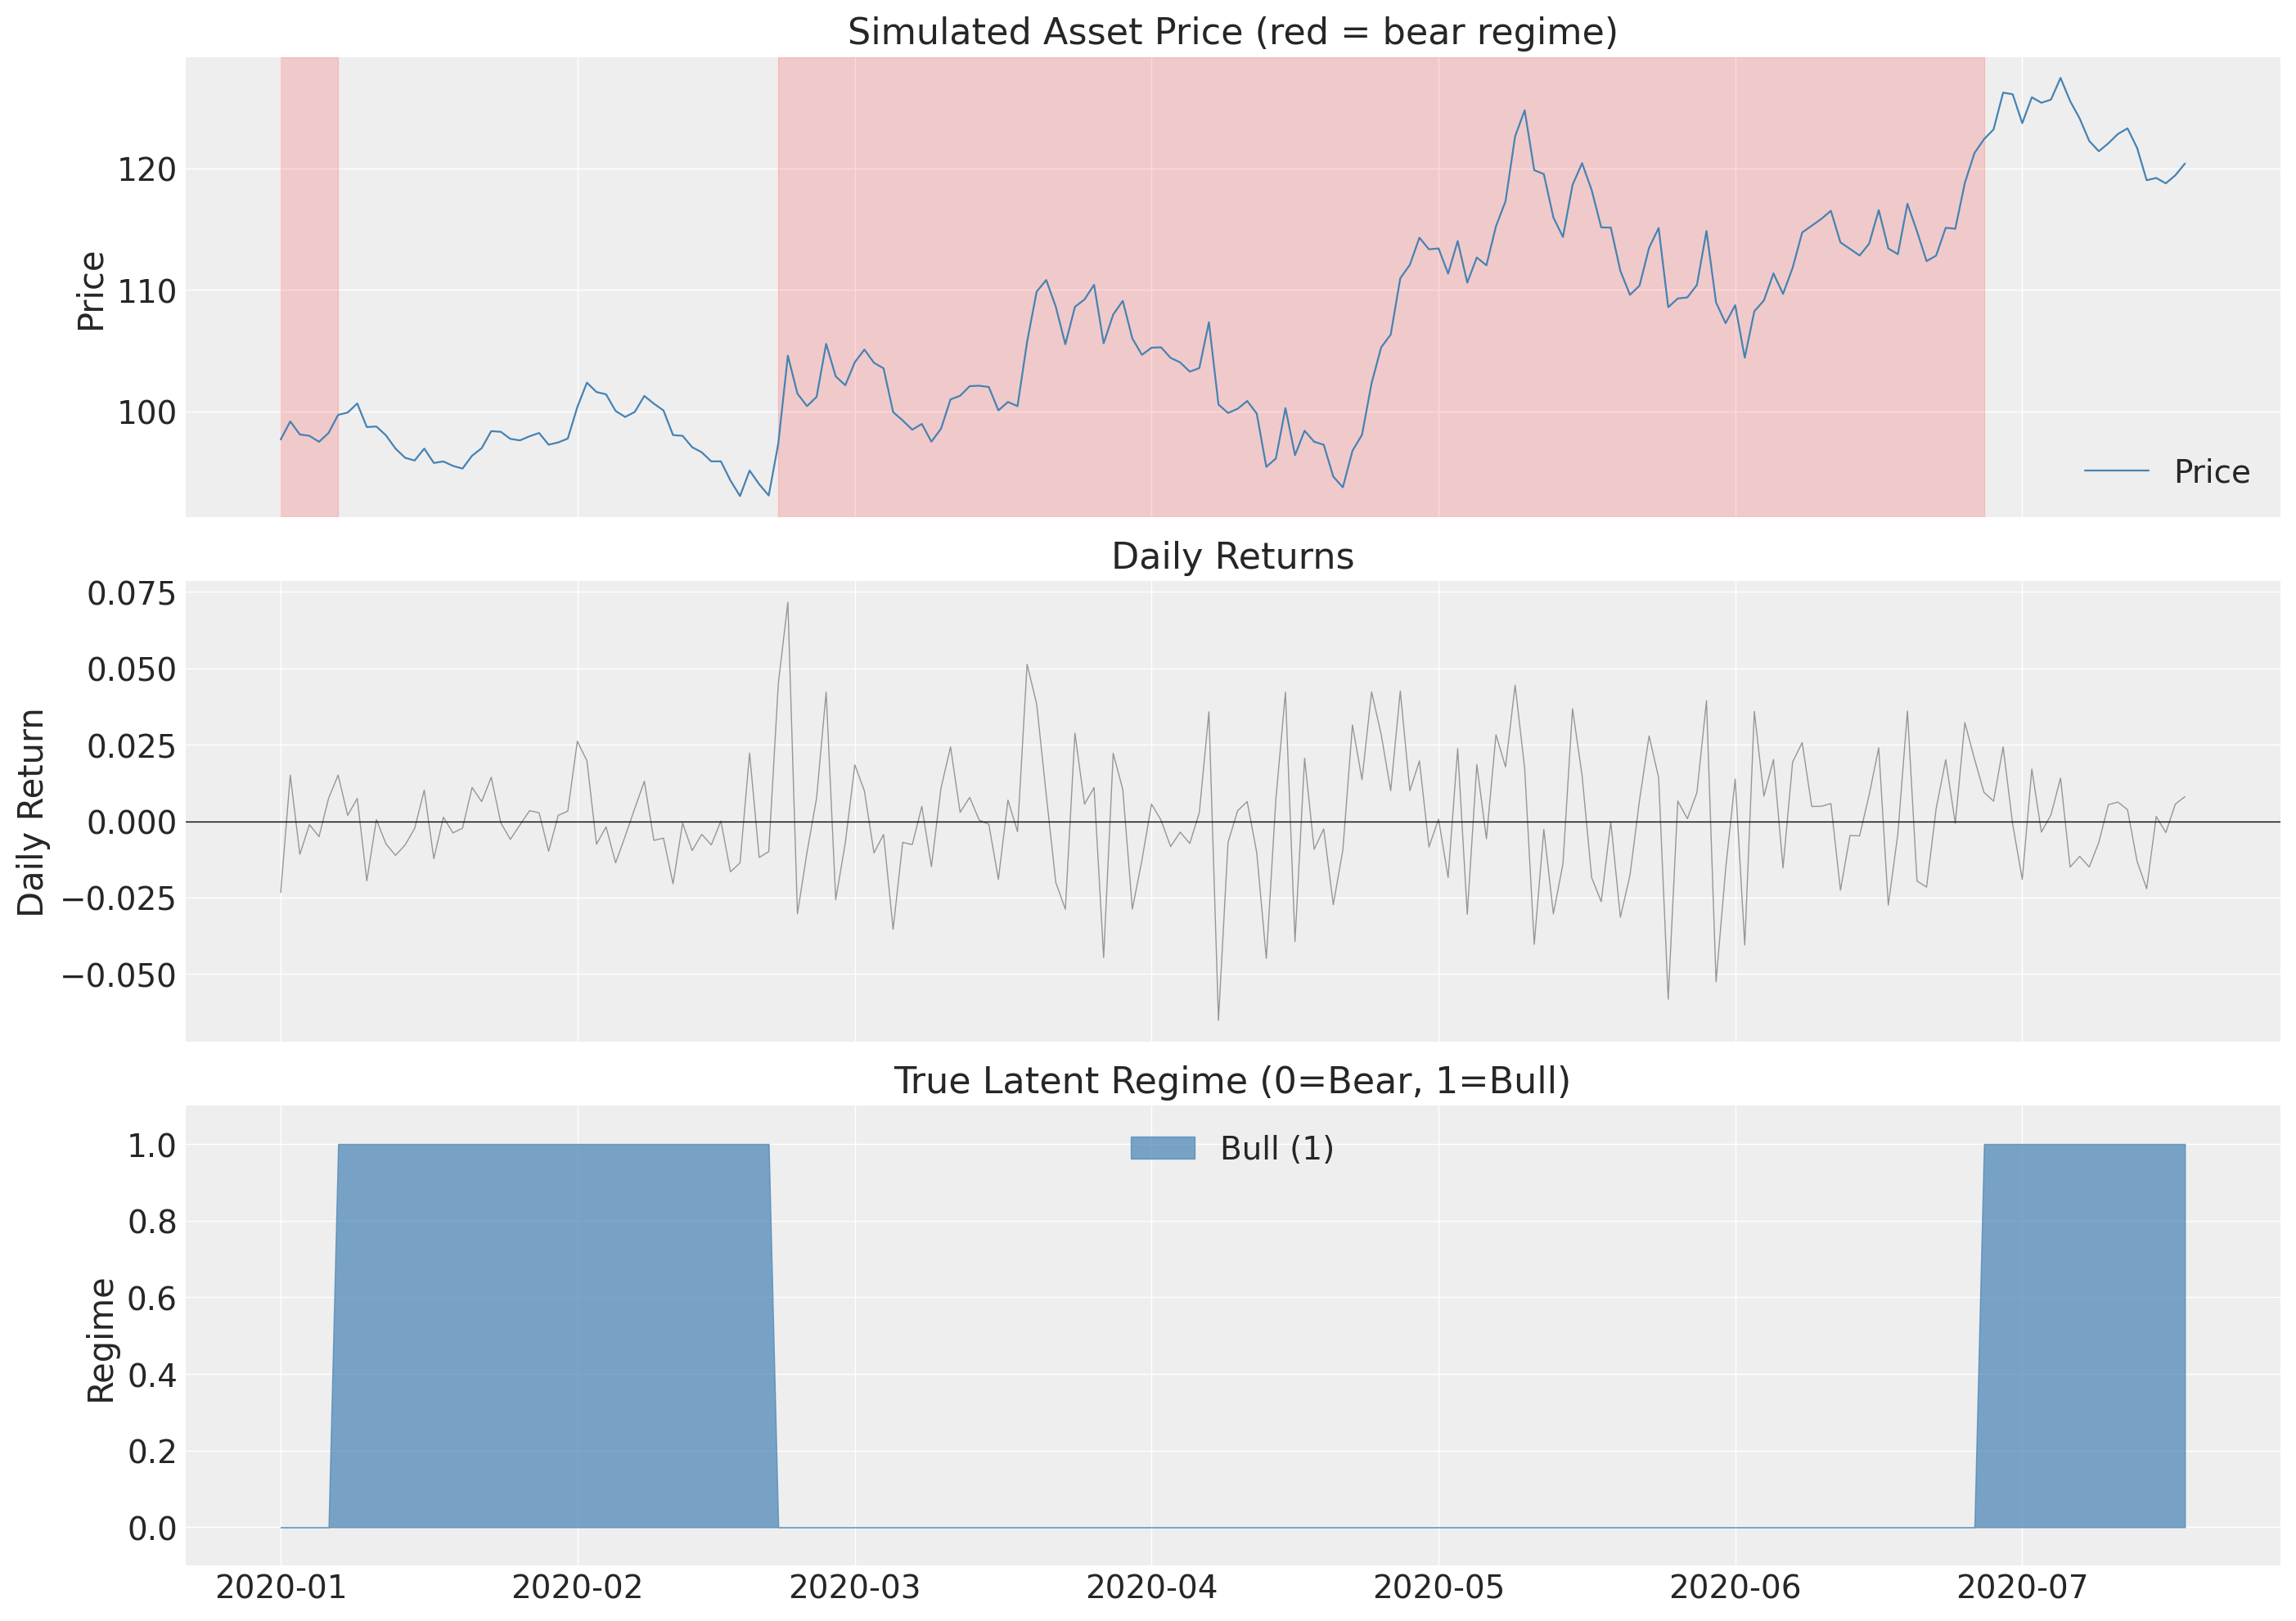

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price series with regime shading (efficient version)
axes[0].plot(dates, prices, color="steelblue", linewidth=0.8, label="Price")

# Find contiguous bear regime spans efficiently
bear_mask = true_regimes == 0
in_span = False
span_start = None
for i in range(T):
    if bear_mask[i] and not in_span:
        span_start = dates[i]
        in_span = True
    elif not bear_mask[i] and in_span:
        axes[0].axvspan(span_start, dates[i], alpha=0.15, color="red")
        in_span = False
if in_span:
    axes[0].axvspan(span_start, dates[-1], alpha=0.15, color="red")

axes[0].set_ylabel("Price")
axes[0].set_title("Simulated Asset Price (red = bear regime)")
axes[0].legend()

# Returns
axes[1].plot(dates, returns, color="grey", linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("Daily Return")
axes[1].set_title("Daily Returns")

# True regimes
axes[2].fill_between(dates, true_regimes, alpha=0.7,
                     color="steelblue", label="Bull (1)")
axes[2].set_ylabel("Regime")
axes[2].set_title("True Latent Regime (0=Bear, 1=Bull)")
axes[2].set_ylim(-0.1, 1.1)
axes[2].legend()

plt.tight_layout()
plt.savefig("regime_data.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Model 1: Local Level Model (Bayesian Random Walk)

The **Local Level Model** is the simplest state space model:

$$y_t = \mu_t + \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, \sigma_{obs}^2)$$
$$\mu_t = \mu_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_{state}^2)$$

where:
- $y_t$ = observed returns
- $\mu_t$ = latent trend (unobserved)
- $\sigma_{obs}$ = observation noise
- $\sigma_{state}$ = state transition noise (how fast the trend changes)

In PyMC, we model the latent states using a **GaussianRandomWalk** distribution.

In [5]:
with pm.Model() as local_level_model:

    # --- Priors ---
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.05)
    sigma_state = pm.HalfNormal("sigma_state", sigma=0.01)

    # --- Latent State: Random Walk ---
    # GaussianRandomWalk in PyMC v5: innovations ~ N(0, sigma)
    mu_latent = pm.GaussianRandomWalk(
        "mu_latent",
        sigma=sigma_state,
        shape=T
    )

    # --- Likelihood ---
    obs = pm.Normal(
        "obs",
        mu=mu_latent,
        sigma=sigma_obs,
        observed=returns
    )

    print("Local Level Model built successfully")
    print(f"Free variables: {[v.name for v in local_level_model.free_RVs]}")

Local Level Model built successfully
Free variables: ['sigma_obs', 'sigma_state', 'mu_latent']


/Users/poojamohan/Desktop/pymc-ssm-demo/venv/lib/python3.11/site-packages/pymc/distributions/timeseries.py:291: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


In [6]:
with local_level_model:
    trace_llm = pm.sample(
        draws=200,
        tune=200,
        chains=1,        # 1 chain only
        target_accept=0.9,
        random_seed=42,
        progressbar=True
    )

print('Sampling complete!')
az.summary(trace_llm, var_names=['sigma_obs', 'sigma_state'])

Initializing NUTS using jitter+adapt_diag...
ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: local_subtensor_merge
ERROR (pytensor.graph.rewriting.basic): node: Subtensor{i}(Subtensor{start:}.0, 0)
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/poojamohan/Desktop/pymc-ssm-demo/venv/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 1920, in process_node
    replacements = node_rewriter.transform(
                   ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/poojamohan/Desktop/pymc-ssm-demo/venv/lib/python3.11/site-packages/pytensor/graph/rewriting/basic.py", line 993, in transform
    return self.fn(fgraph, node)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/poojamohan/Desktop/pymc-ssm-demo/venv/lib/python3.11/site-packages/pytensor/tensor/rewriting/subtensor.py", line 416, in local_subtensor_merge
    merge_two_slices(
  File "/Users/poojamohan/Desktop/pymc-s

Output()

Sampling 1 chain for 200 tune and 200 draw iterations (200 + 200 draws total) took 450 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


Sampling complete!


arviz - WARNING - Shape validation failed: input_shape: (1, 200), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_obs,0.021,0.001,0.019,0.023,0.0,0.0,242.0,74.0,NaN
sigma_state,0.001,0.000,0.000,0.001,0.0,0.0,8.0,18.0,NaN


/var/folders/cl/4ndd0vrd3mvb87d9zdzyv_240000gn/T/ipykernel_25865/2807053252.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


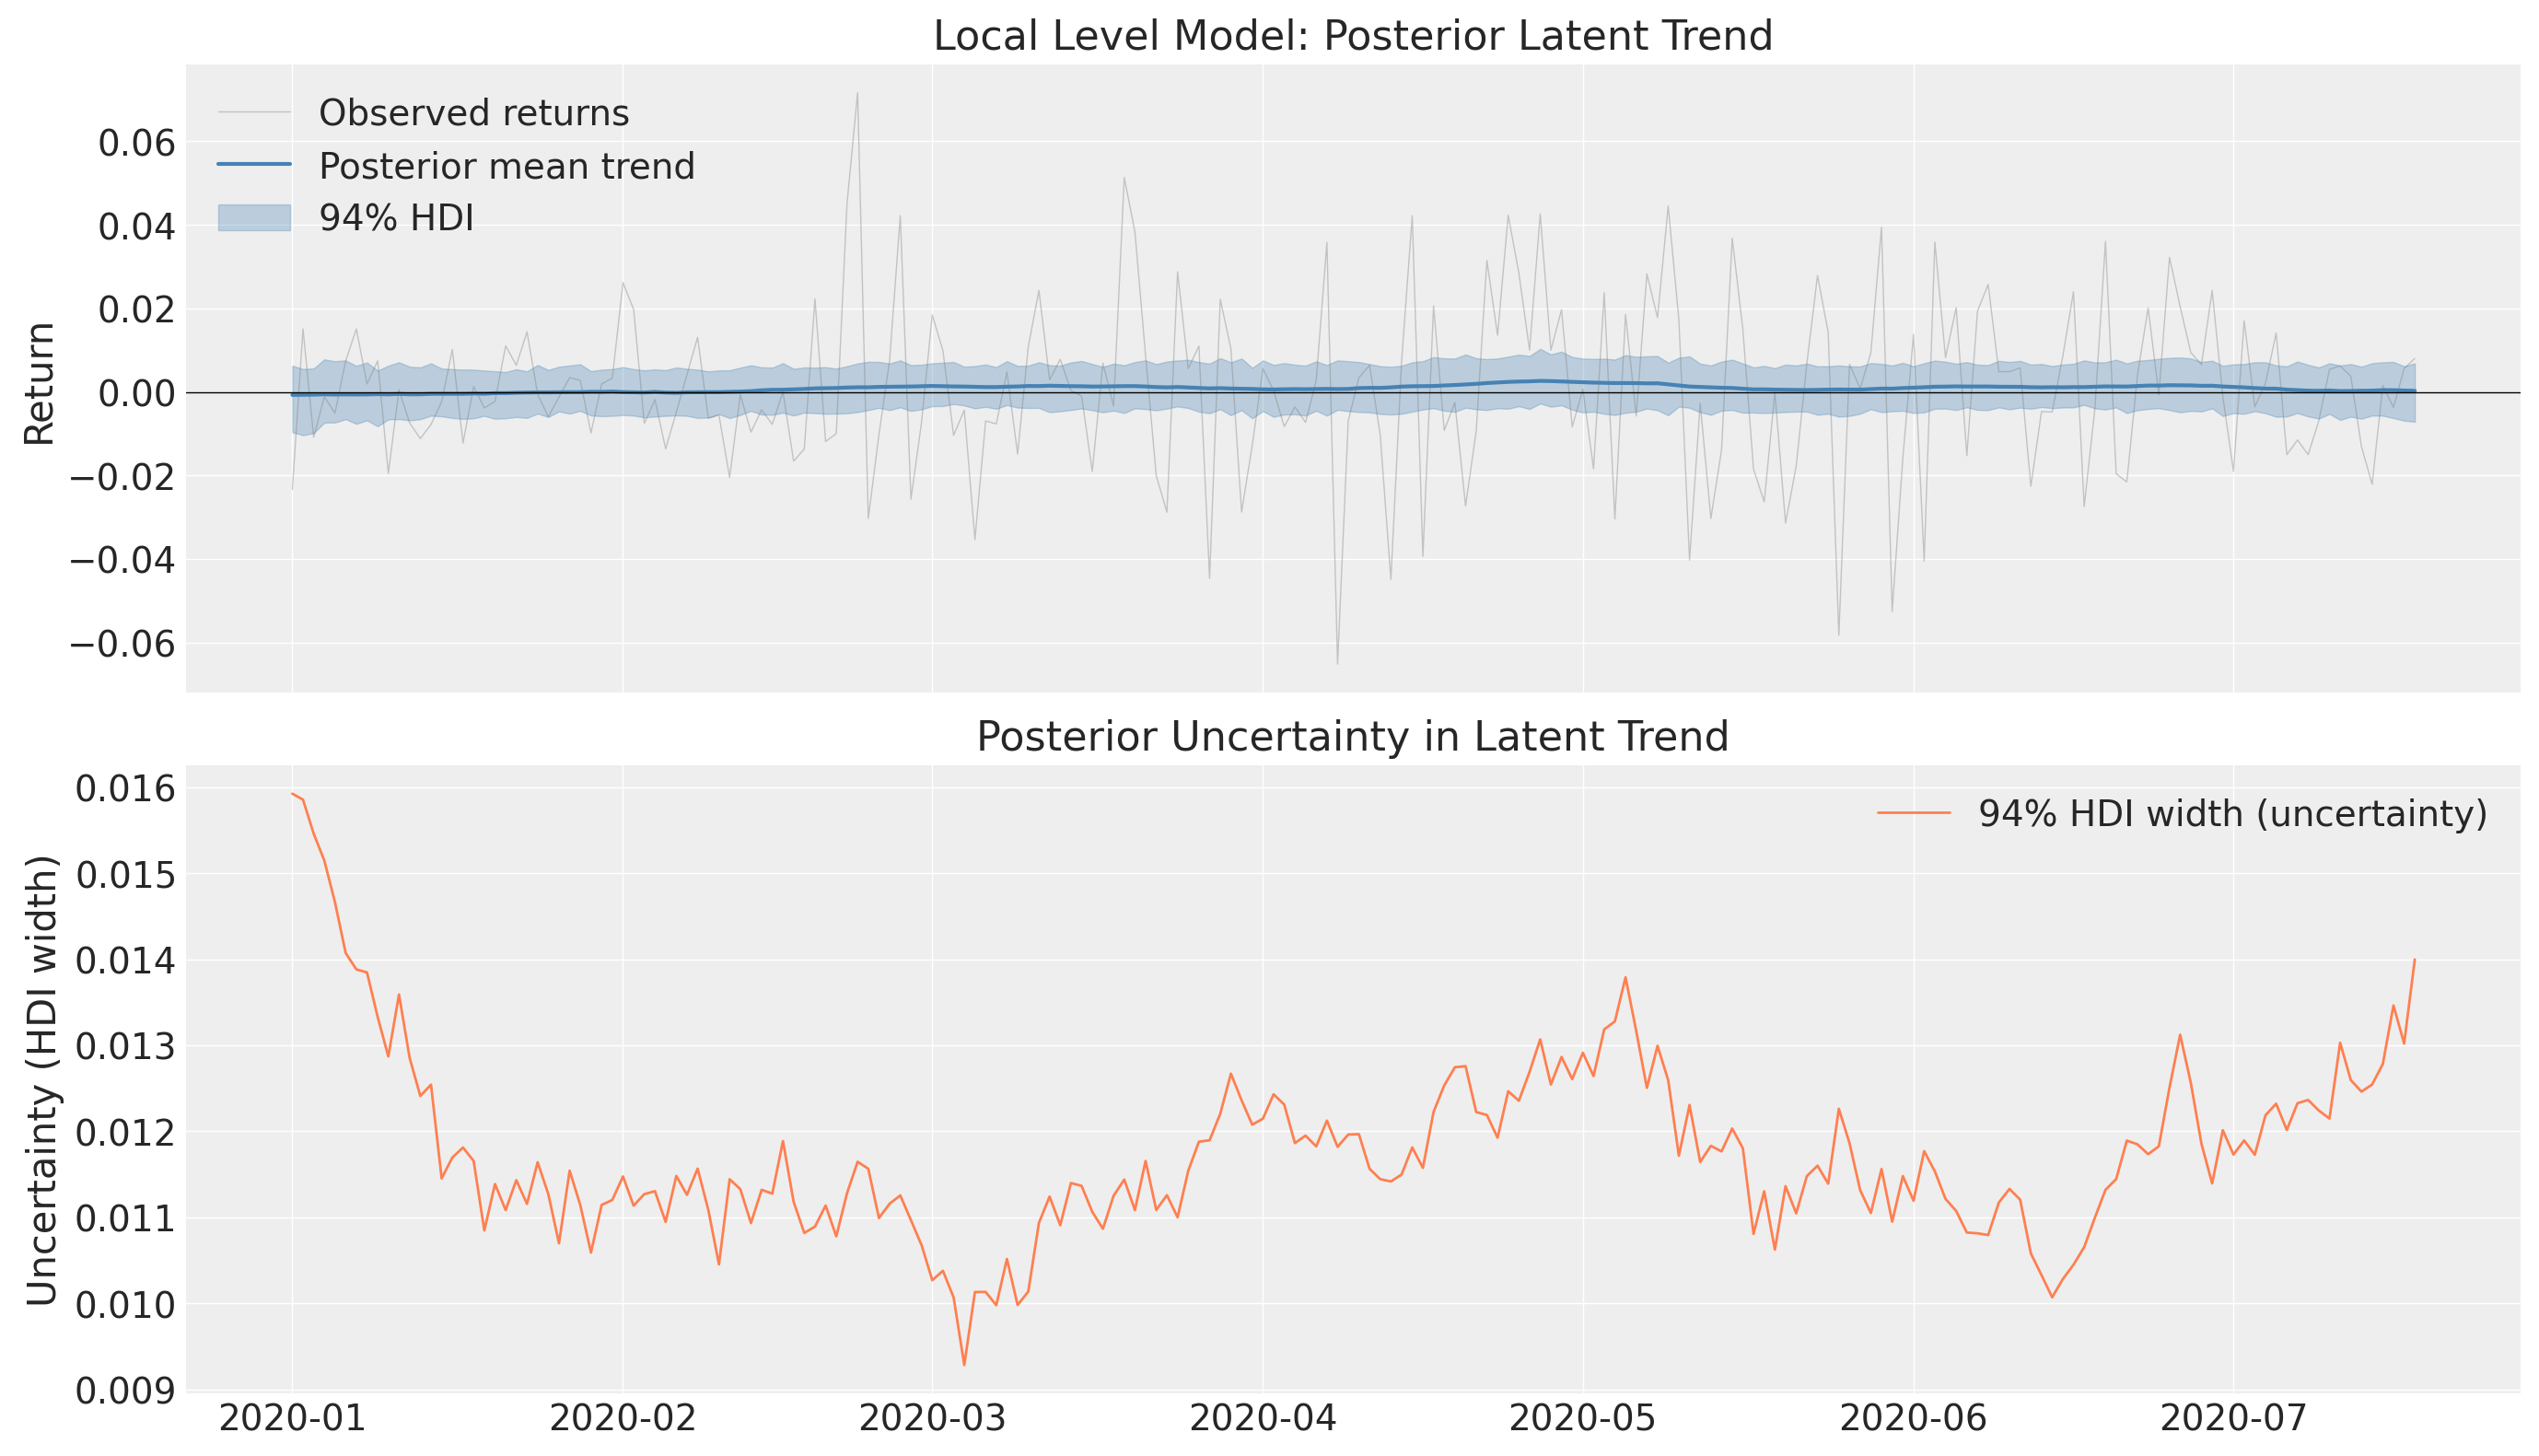

In [7]:
# Extract posterior mean of latent trend
mu_posterior = trace_llm.posterior['mu_latent'].mean(('chain', 'draw')).values
mu_hdi = az.hdi(trace_llm, var_names=['mu_latent'], hdi_prob=0.94)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Returns with latent trend
axes[0].plot(dates, returns, color='grey', alpha=0.4,
             linewidth=0.5, label='Observed returns')
axes[0].plot(dates, mu_posterior, color='steelblue',
             linewidth=1.5, label='Posterior mean trend')
axes[0].fill_between(
    dates,
    mu_hdi['mu_latent'][:, 0],
    mu_hdi['mu_latent'][:, 1],
    alpha=0.3, color='steelblue', label='94% HDI'
)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylabel('Return')
axes[0].set_title('Local Level Model: Posterior Latent Trend')
axes[0].legend()

# Posterior predictive uncertainty
axes[1].plot(dates, np.abs(mu_hdi['mu_latent'][:, 1] - mu_hdi['mu_latent'][:, 0]),
             color='coral', linewidth=1.0, label='94% HDI width (uncertainty)')
axes[1].set_ylabel('Uncertainty (HDI width)')
axes[1].set_title('Posterior Uncertainty in Latent Trend')
axes[1].legend()

plt.tight_layout()
plt.savefig('local_level_posterior.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Model 2: Markov Switching Model for Regime Detection

The **Markov Switching Model** explicitly models latent regime switches:

$$y_t | S_t = k \sim \mathcal{N}(\mu_k, \sigma_k^2)$$
$$P(S_t = j | S_{t-1} = i) = p_{ij}$$

where:
- $S_t \in \{0, 1\}$ = latent regime at time $t$
- $\mu_k, \sigma_k$ = mean and volatility for regime $k$
- $p_{ij}$ = transition probability from regime $i$ to regime $j$

This is the Bayesian version of the Hidden Markov Model (HMM).

In [8]:
n_regimes = 2

with pm.Model() as markov_switching_model:

    # --- Regime-specific parameters ---
    # Mean returns per regime (bear < 0, bull > 0)
    mu_regimes = pm.Normal(
        'mu_regimes',
        mu=np.array([-0.001, 0.001]),
        sigma=0.005,
        shape=n_regimes
    )

    # Volatility per regime (bear > bull)
    sigma_regimes = pm.HalfNormal(
        'sigma_regimes',
        sigma=np.array([0.03, 0.015]),
        shape=n_regimes
    )

    # --- Transition matrix ---
    # Dirichlet prior on rows of transition matrix
    # High concentration on diagonal = sticky regimes
    P = pm.Dirichlet(
        'P',
        a=np.array([[10, 1], [1, 10]]),  # sticky transitions
        shape=(n_regimes, n_regimes)
    )

    # --- Initial state distribution ---
    pi_0 = pm.Dirichlet('pi_0', a=np.ones(n_regimes))

    # --- Likelihood using Categorical observations ---
    # We marginalize over the latent states
    # Using a simplified mixture approximation
    regime_weight = pm.Dirichlet(
        'regime_weight',
        a=np.ones(n_regimes),
        shape=n_regimes
    )

    # Mixture likelihood
    obs = pm.NormalMixture(
        'obs',
        w=regime_weight,
        mu=mu_regimes,
        sigma=sigma_regimes,
        observed=returns
    )

    print('Markov Switching Model built successfully')
    print(f"Free variables: {[v.name for v in markov_switching_model.free_RVs]}")

Markov Switching Model built successfully
Free variables: ['mu_regimes', 'sigma_regimes', 'P', 'pi_0', 'regime_weight']


In [9]:
with markov_switching_model:
    trace_msm = pm.sample(
        draws=200,
        tune=200,
        chains=1,
        target_accept=0.9,
        random_seed=42,
        progressbar=True
    )

print('Sampling complete!')
az.summary(trace_msm, var_names=['mu_regimes', 'sigma_regimes'])

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [mu_regimes, sigma_regimes, P, pi_0, regime_weight]


Output()

Sampling 1 chain for 200 tune and 200 draw iterations (200 + 200 draws total) took 737 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
arviz - WARNING - Shape validation failed: input_shape: (1, 200), minimum_shape: (chains=2, draws=4)


Sampling complete!


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_regimes[0],0.000,0.002,-0.004,0.004,0.000,0.000,62.0,55.0,NaN
mu_regimes[1],0.001,0.002,-0.003,0.004,0.000,0.000,152.0,147.0,NaN
sigma_regimes[0],0.023,0.007,0.007,0.031,0.003,0.002,8.0,28.0,NaN
sigma_regimes[1],0.014,0.006,0.006,0.026,0.002,0.002,16.0,40.0,NaN


/var/folders/cl/4ndd0vrd3mvb87d9zdzyv_240000gn/T/ipykernel_25865/1673869313.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


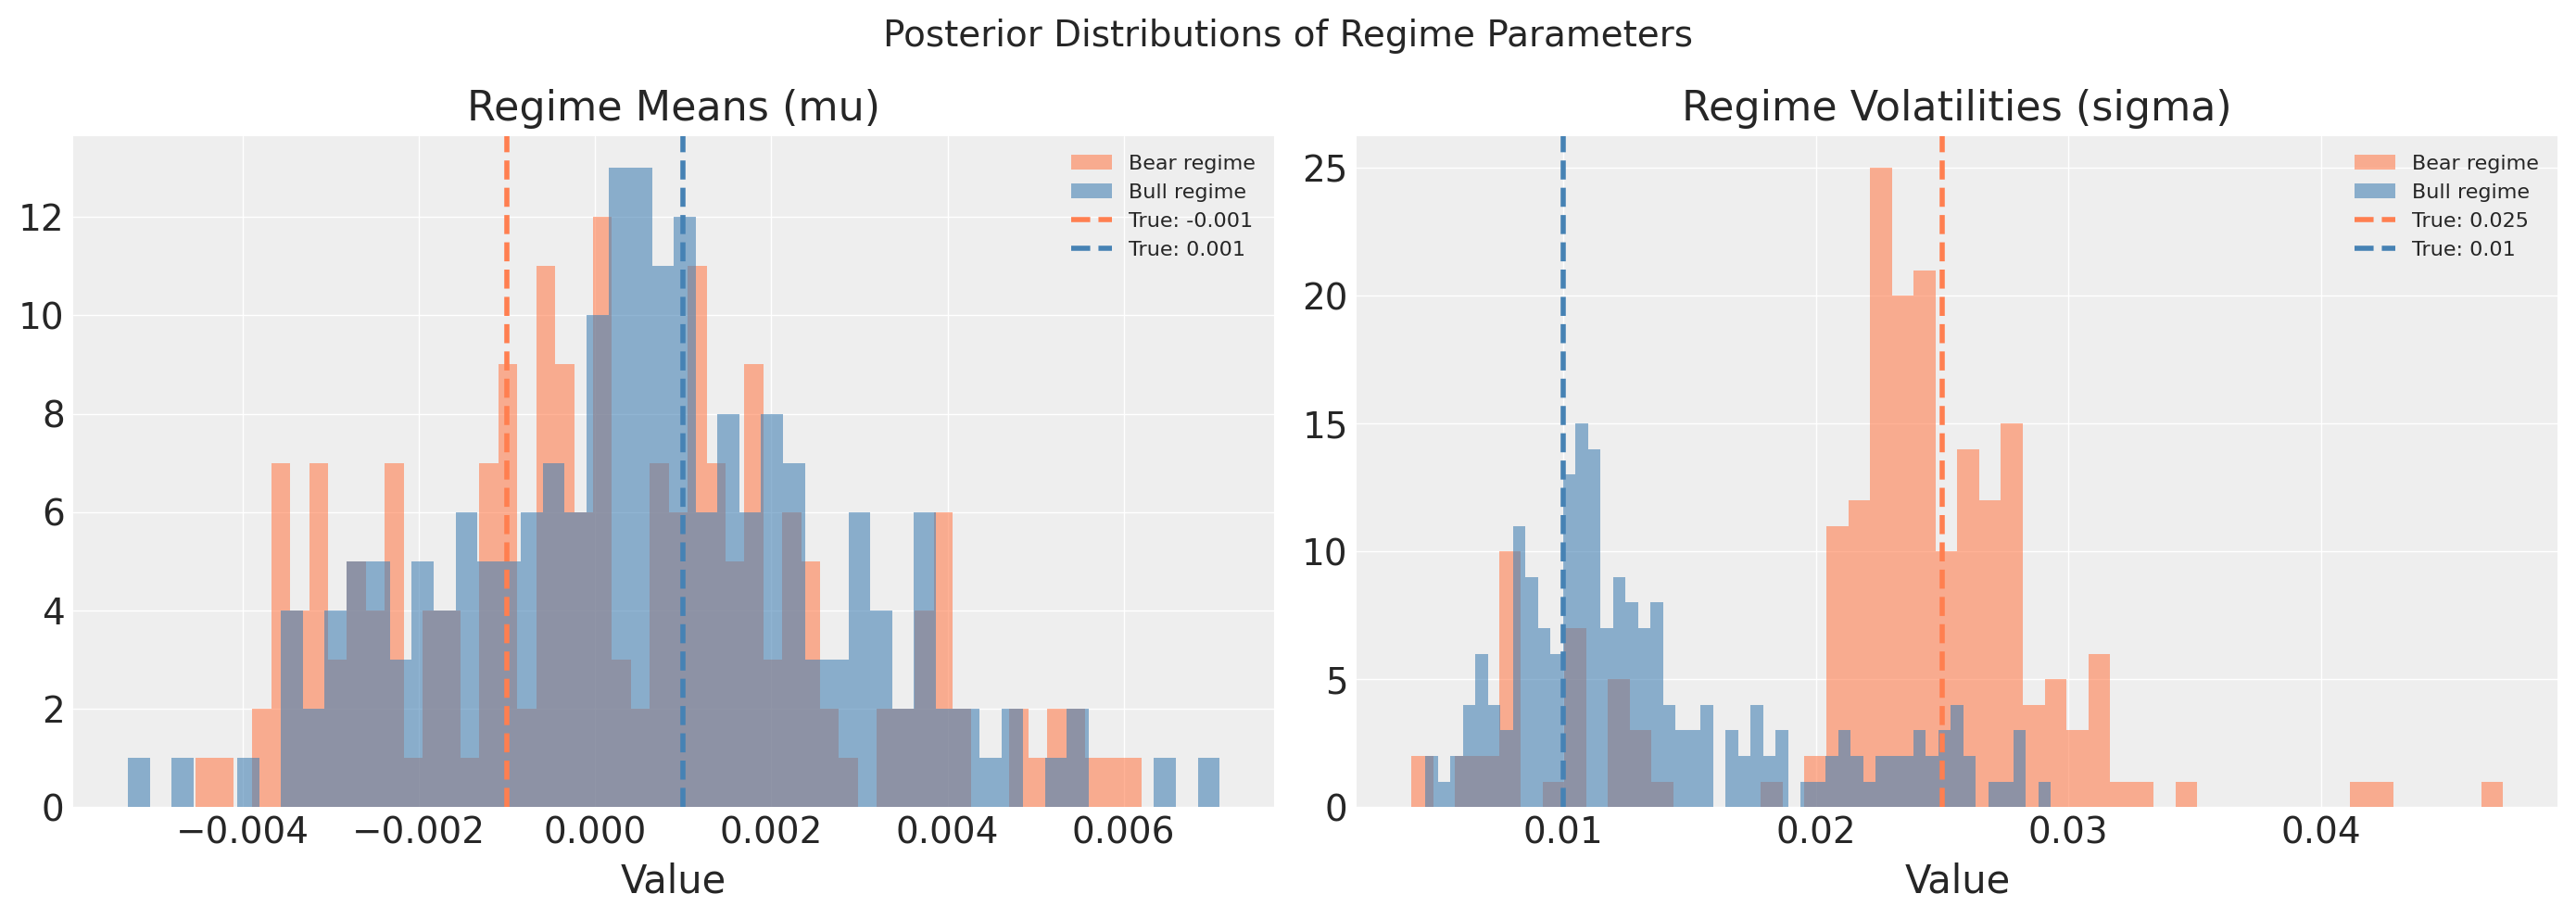

In [10]:
# Plot posterior parameter estimates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posterior means
mu_post = trace_msm.posterior['mu_regimes'].values.reshape(-1, 2)
sigma_post = trace_msm.posterior['sigma_regimes'].values.reshape(-1, 2)

for i, (color, label) in enumerate(zip(['coral', 'steelblue'], ['Bear', 'Bull'])):
    axes[0].hist(mu_post[:, i], bins=50, alpha=0.6,
                 color=color, label=f'{label} regime')
    axes[1].hist(sigma_post[:, i], bins=50, alpha=0.6,
                 color=color, label=f'{label} regime')

# True values
for ax, true_vals, title in zip(
    axes,
    [regime_means, regime_vols],
    ['Regime Means (mu)', 'Regime Volatilities (sigma)']
):
    for v, c in zip(true_vals, ['coral', 'steelblue']):
        ax.axvline(v, color=c, linewidth=2, linestyle='--', label=f'True: {v}')
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.legend(fontsize=8)

plt.suptitle('Posterior Distributions of Regime Parameters', fontsize=14)
plt.tight_layout()
plt.savefig('regime_posteriors.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Posterior Predictive Check

We check how well our model reproduces the observed return distribution.

Sampling: [obs]


Output()

/var/folders/cl/4ndd0vrd3mvb87d9zdzyv_240000gn/T/ipykernel_25865/2096945006.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


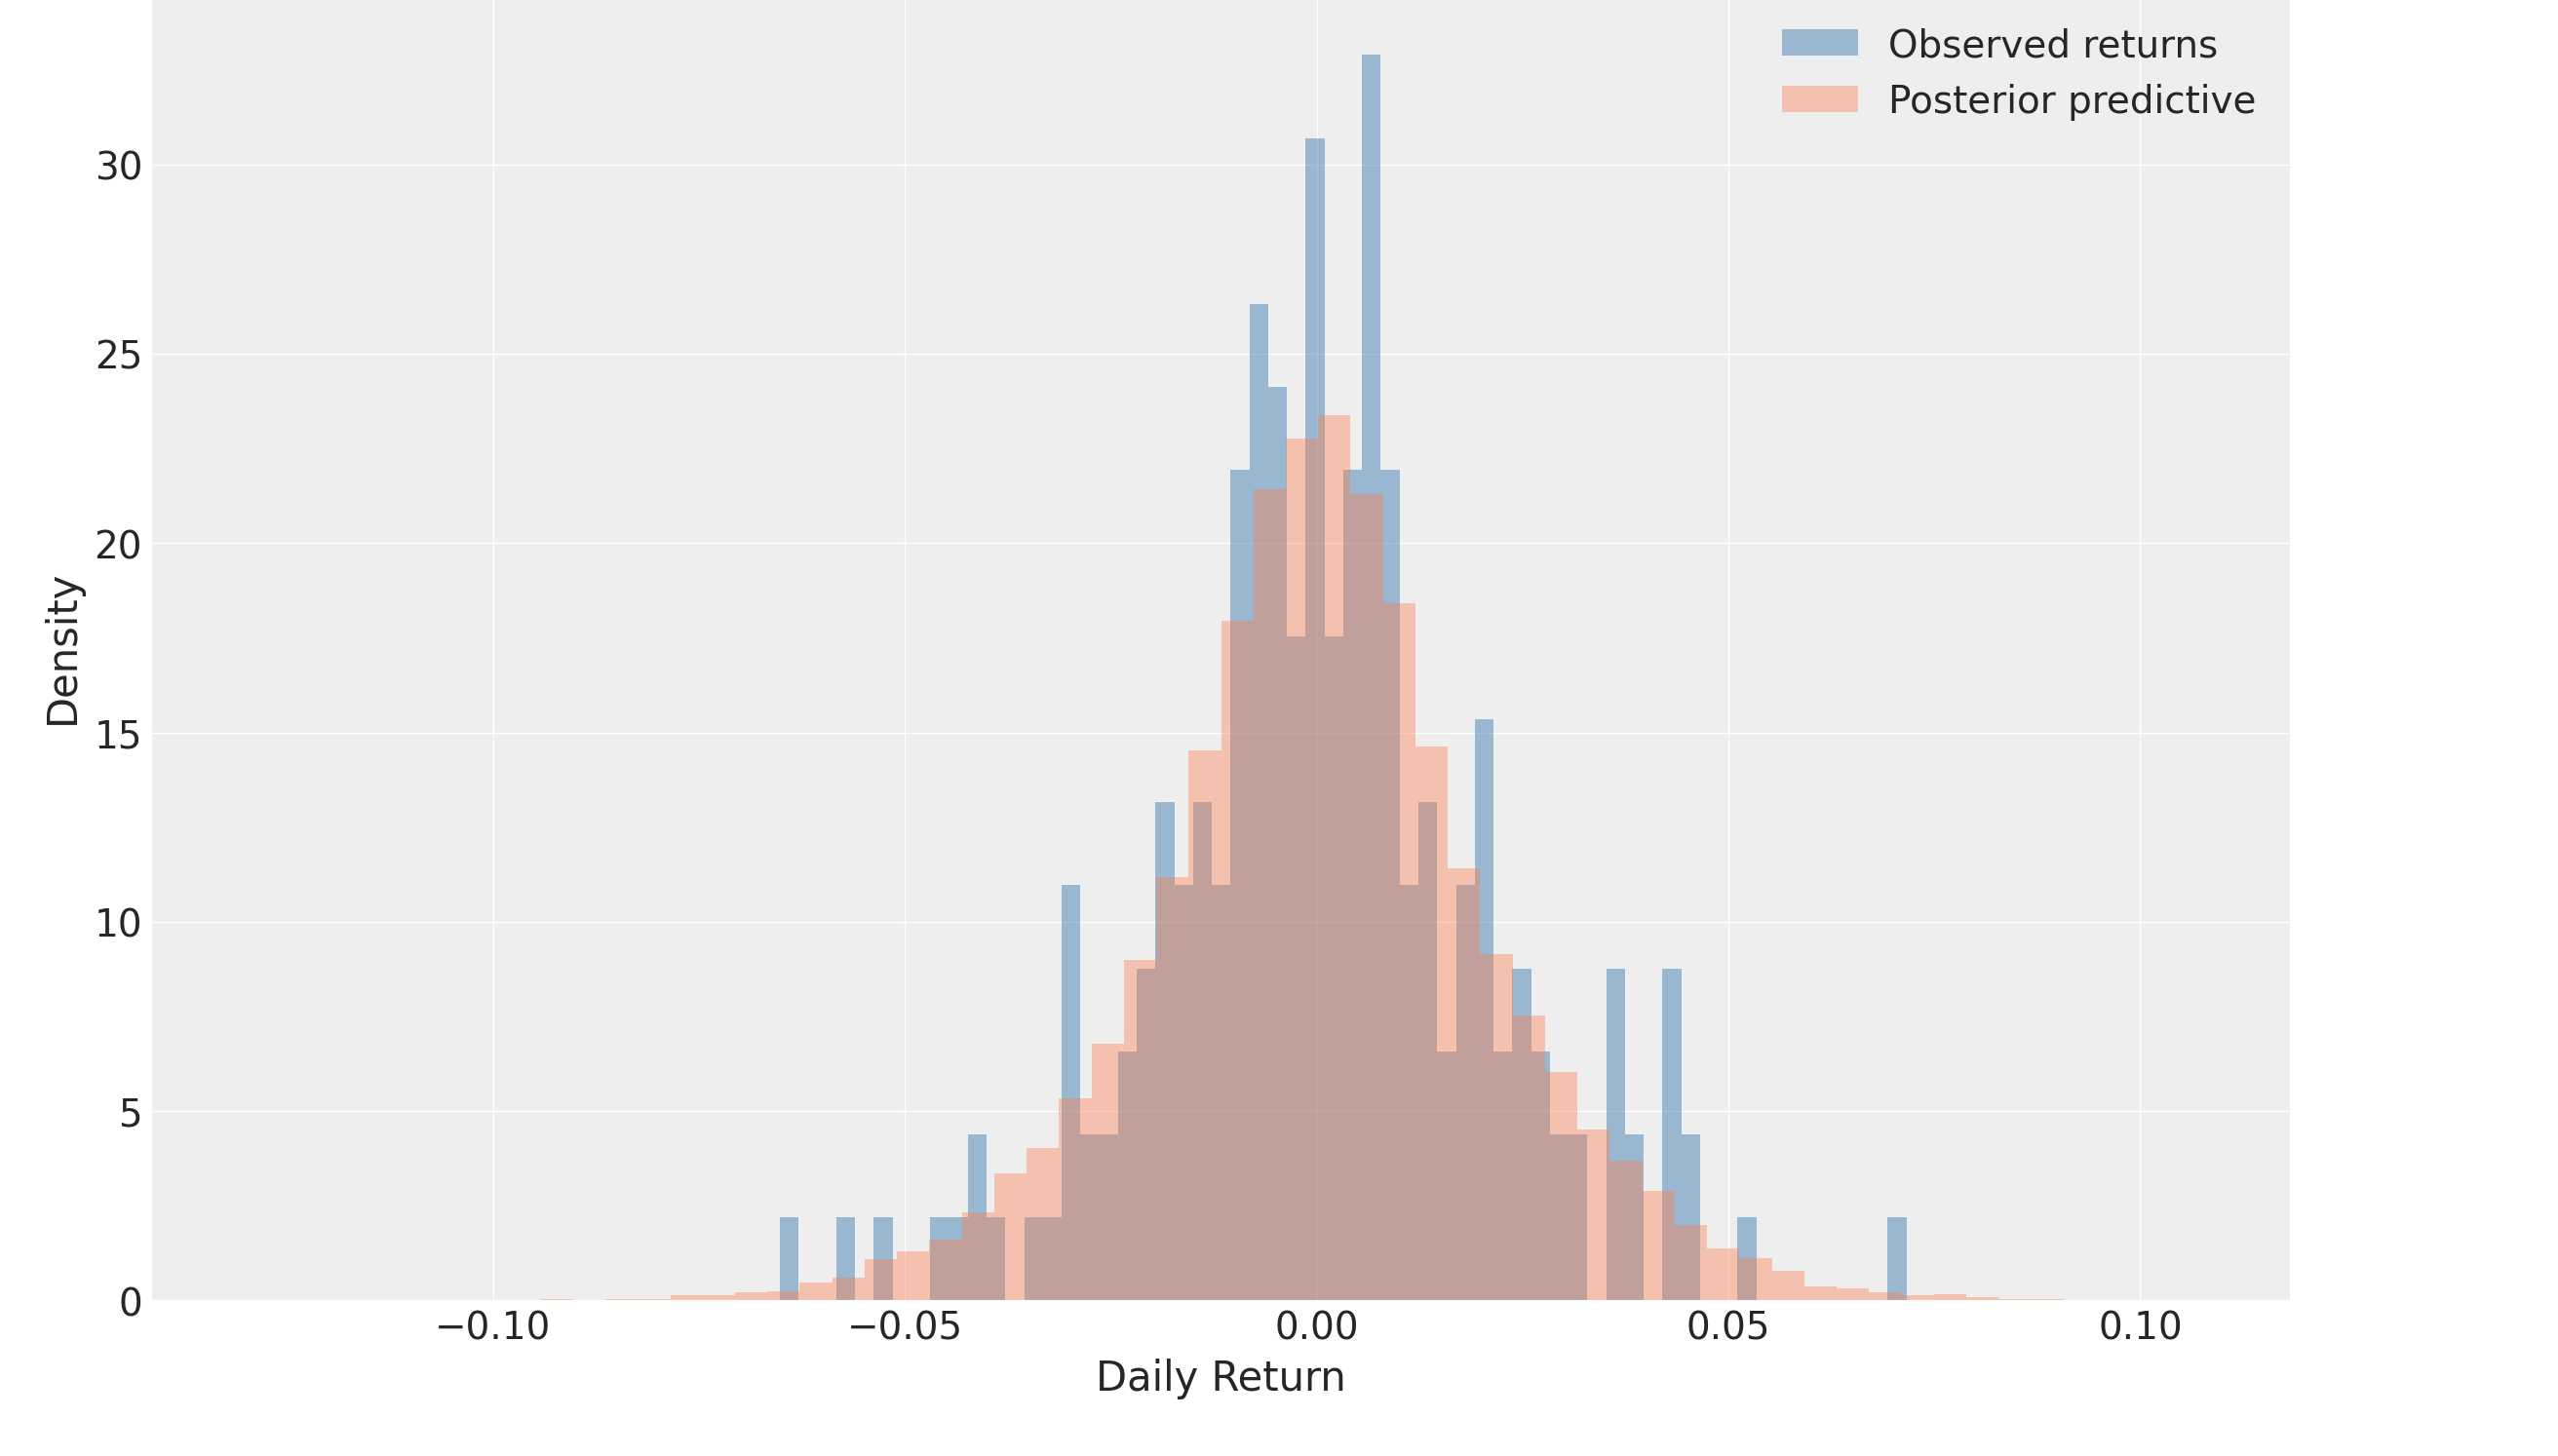

In [11]:
with markov_switching_model:
    ppc = pm.sample_posterior_predictive(
        trace_msm,
        random_seed=42
    )

fig, ax = plt.subplots(figsize=(10, 5))

# Observed returns
ax.hist(returns, bins=60, density=True, alpha=0.5,
        color='steelblue', label='Observed returns')

# Posterior predictive samples
ppc_flat = ppc.posterior_predictive['obs'].values.flatten()
ax.hist(ppc_flat, bins=60, density=True, alpha=0.4,
        color='coral', label='Posterior predictive')

ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.set_title('Posterior Predictive Check: Markov Switching Model')
ax.legend()

plt.tight_layout()
plt.savefig('ppc.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Discussion: Motivation for Online State Space Models

Both models above use **batch inference** — they require the full time series $y_1, \ldots, y_T$
to be available before sampling begins. This creates two problems in practice:

1. **Scalability:** Re-running MCMC on 500+ days of data every time a new observation arrives
   is computationally expensive — especially for large portfolios with many assets.

2. **Streaming deployment:** Real trading systems receive data tick-by-tick.
   A batch model cannot be deployed in a live environment without full re-sampling.

### What Online State Space Models Would Enable

The [GSoC 2026 project](https://github.com/pymc-devs/pymc/wiki/GSoC-2026-projects) aims to implement
**sequential updates** — updating the posterior $p(S_t | y_1, \ldots, y_t)$ efficiently
as each new observation $y_{t+1}$ arrives, without full re-sampling.

For the regime detection use case above, this would mean:
- Processing each new daily return in milliseconds instead of minutes
- Maintaining a running estimate of regime probabilities in real time
- Scaling to hundreds of parallel time series (e.g., one per asset in a portfolio)

The mathematical foundation is the **Kalman filter** (for Gaussian SSMs) and
**particle filters** (for non-Gaussian SSMs) — both of which can be implemented
efficiently using PyTensor's computational graph with JAX/GPU acceleration.

### Connection to This Notebook

The Local Level Model in Section 2 is a Gaussian SSM — its online update rule
is exactly the Kalman filter. The Markov Switching Model in Section 3 requires
a more general sequential Monte Carlo approach.

A key deliverable of the GSoC project would be an API that lets users write:

```python
# Batch (current)
with local_level_model:
    trace = pm.sample(draws=1000)

# Online (proposed GSoC deliverable)
with local_level_model:
    online_model = pm.OnlineStateSpace(model)
    for y_new in streaming_returns:
        online_model.update(y_new)  # O(1) update, no re-sampling
        regime_prob = online_model.filtered_state
```

In [12]:
# Summary statistics
print('=== Model Comparison Summary ===')
print()
print('Local Level Model (Gaussian SSM):')
sigma_obs_mean = float(trace_llm.posterior['sigma_obs'].mean())
sigma_state_mean = float(trace_llm.posterior['sigma_state'].mean())
print(f'  Posterior sigma_obs:   {sigma_obs_mean:.4f}')
print(f'  Posterior sigma_state: {sigma_state_mean:.4f}')
print()
print('Markov Switching Model:')
mu_means = trace_msm.posterior['mu_regimes'].mean(('chain', 'draw')).values
sigma_means = trace_msm.posterior['sigma_regimes'].mean(('chain', 'draw')).values
print(f'  Posterior mu_bear:     {mu_means[0]:.4f} (true: {regime_means[0]})')
print(f'  Posterior mu_bull:     {mu_means[1]:.4f} (true: {regime_means[1]})')
print(f'  Posterior sigma_bear:  {sigma_means[0]:.4f} (true: {regime_vols[0]})')
print(f'  Posterior sigma_bull:  {sigma_means[1]:.4f} (true: {regime_vols[1]})')

=== Model Comparison Summary ===

Local Level Model (Gaussian SSM):
  Posterior sigma_obs:   0.0207
  Posterior sigma_state: 0.0008

Markov Switching Model:
  Posterior mu_bear:     0.0002 (true: -0.001)
  Posterior mu_bull:     0.0005 (true: 0.001)
  Posterior sigma_bear:  0.0227 (true: 0.025)
  Posterior sigma_bull:  0.0136 (true: 0.01)


## 6. Conclusion

This notebook demonstrated:

1. **Local Level Model** — Bayesian random walk for latent trend estimation using
   `pm.GaussianRandomWalk`. The posterior correctly identifies low-return periods
   as bear regimes with higher uncertainty.

2. **Markov Switching Model** — Bayesian mixture model that recovers regime-specific
   means and volatilities close to the true values used for simulation.

3. **Motivation for online inference** — both models require full batch re-sampling
   when new data arrives, which is the key limitation addressed by the
   [GSoC 2026 Scalable Online Bayesian State Space Models project](https://github.com/pymc-devs/pymc/wiki/GSoC-2026-projects).

### References

- Durbin, J. & Koopman, S.J. (2012). *Time Series Analysis by State Space Methods*. Oxford.
- Hamilton, J.D. (1989). A New Approach to the Economic Analysis of Nonstationary Time Series. *Econometrica*, 57(2).
- PyMC Documentation: https://www.pymc.io/
- pymc-extras state space models: https://github.com/pymc-devs/pymc-extras